# Assignment 7
* Student: **Danilo Tambone**
* NetID: **PWC25003**

The work contained and presented here is my work and my work alone.

In [1]:
import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
import statsmodels.api as sm

from pylab import * # for data viz (import * means 'import all of the functions')
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc,accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, make_scorer
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from scipy import stats
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

In [2]:
# mount your google drive
from google.colab import drive
drive.mount('/content/drive')
# read data
# on the lefthand side, navigate to your data and copy the path
df = pd.read_csv('/content/drive/MyDrive/Predictive Modeling/M7/Telco_customer_churn.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Read in the Telco dataset and determine how many rows and columns it has.


In [3]:
rows, cols = df.shape

print(f"The Telco dataset has {rows} rows and {cols} columns.")

The Telco dataset has 7043 rows and 18 columns.


2. Partition the data into a 60/20/20 split.


In [4]:
# Split 1: Isolate 20% for the Test set, leaving 80% for a temporary Train/Val set
temp_df, test_df = train_test_split(df, test_size=0.20, random_state=42)

# Split 2: Take 25% of the temporary 80% to get exactly 20% of the original data for Validation
train_df, val_df = train_test_split(temp_df, test_size=0.25, random_state=42)

# Print the results to verify the split sizes
print(f"Training set:   {train_df.shape[0]} rows (60%)")
print(f"Validation set: {val_df.shape[0]} rows (20%)")
print(f"Testing set:    {test_df.shape[0]} rows (20%)")

Training set:   4225 rows (60%)
Validation set: 1409 rows (20%)
Testing set:    1409 rows (20%)


3. Build a decision tree model to predict churn using all predictors.


Training Accuracy:   0.9974
Validation Accuracy: 0.7551
Number of nodes:     1889
Tree Max Depth:      25


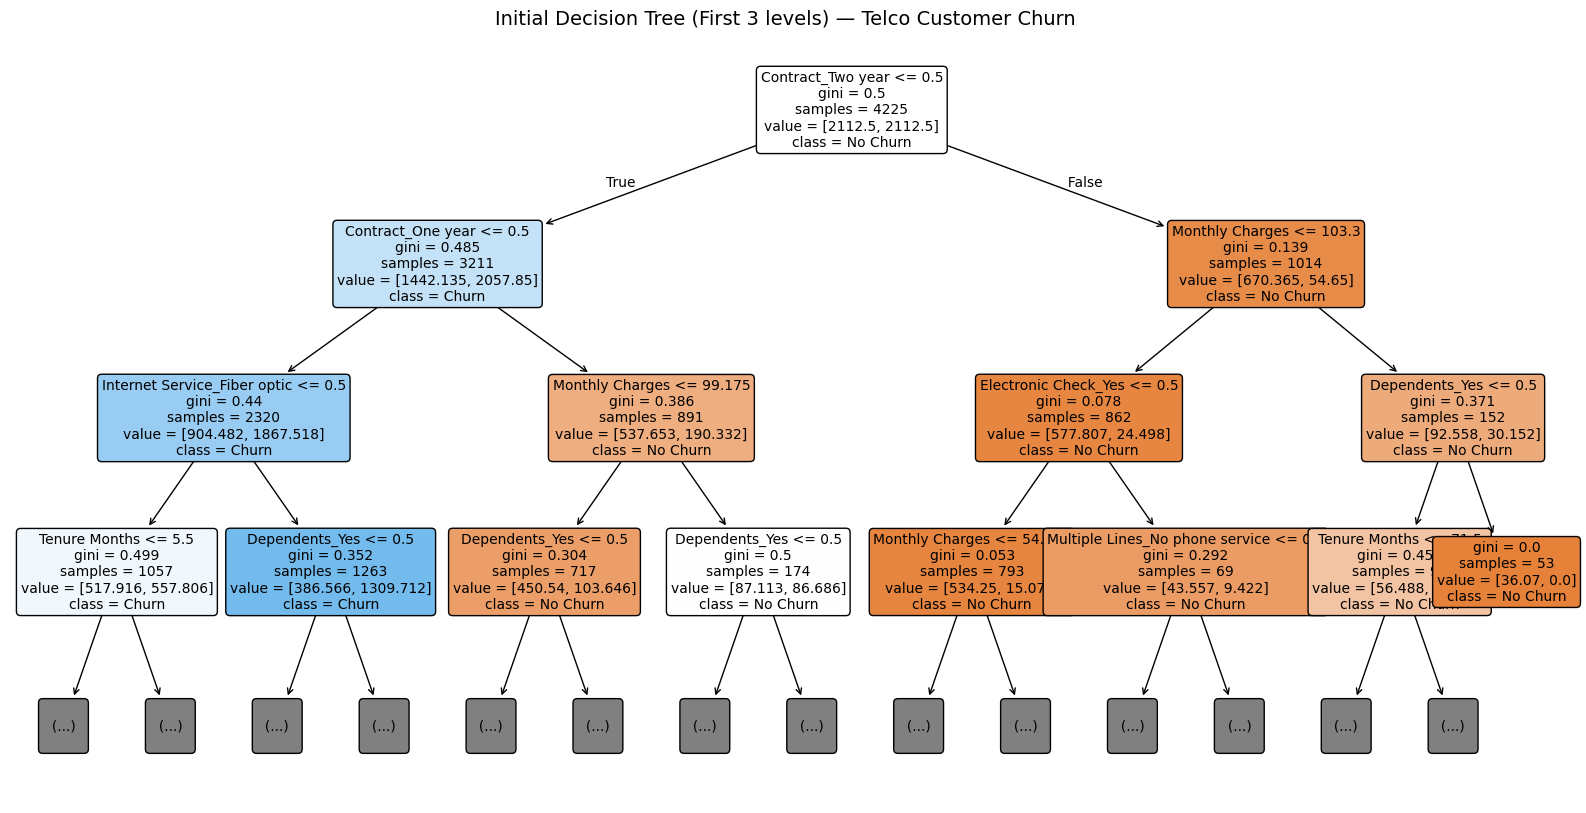

In [5]:
# 1. Clean the dataset
telco_clean = df.drop(columns=['CustomerID', 'Churn Label'])

# 2. Separate Features and Target with unique names
X_telco = telco_clean.drop(columns=['Churn Value'])
y_telco = telco_clean['Churn Value']

# 3. Partition into 60/20/20 split first to prevent data leakage
X_temp_telco, X_test_telco, y_temp_telco, y_test_telco = train_test_split(X_telco, y_telco, test_size=0.20, random_state=42)
X_train_telco, X_val_telco, y_train_telco, y_val_telco = train_test_split(X_temp_telco, y_temp_telco, test_size=0.25, random_state=42)

# 4. Convert categorical text columns to numeric dummy variables after splitting
X_train_telco = pd.get_dummies(X_train_telco, drop_first=True)

# Align validation and test sets to have the exact same dummy columns as the training set
X_val_telco = pd.get_dummies(X_val_telco, drop_first=True).reindex(columns=X_train_telco.columns, fill_value=0)
X_test_telco = pd.get_dummies(X_test_telco, drop_first=True).reindex(columns=X_train_telco.columns, fill_value=0)

# 5. Initialize and Fit the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train_telco, y_train_telco)

# 6. Evaluate initial performance
train_acc = accuracy_score(y_train_telco, dt_model.predict(X_train_telco))
val_acc = accuracy_score(y_val_telco, dt_model.predict(X_val_telco))

print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Number of nodes:     {dt_model.tree_.node_count}")
print(f"Tree Max Depth:      {dt_model.tree_.max_depth}")

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    max_depth=3, # Limiting depth for visibility
    feature_names=list(X_train_telco.columns),
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Initial Decision Tree (First 3 levels) — Telco Customer Churn', fontsize=14)
plt.show()

4. How many splits and rules does the tree have?


In [6]:
# Get the total number of nodes in the tree
total_nodes = dt_model.tree_.node_count

# Get the number of rules (which are the leaf nodes/endpoints of the tree)
num_rules = dt_model.tree_.n_leaves

# Calculate the number of splits (internal nodes)
# Splits = Total Nodes - Leaf Nodes
num_splits = total_nodes - num_rules

# Print the results
print(f"Total Nodes: {total_nodes}")
print(f"Number of Splits (Internal Nodes): {num_splits}")
print(f"Number of Rules (Leaf Nodes): {num_rules}")

Total Nodes: 1889
Number of Splits (Internal Nodes): 944
Number of Rules (Leaf Nodes): 945


5. Check model performance by partition with total accuracy, precision, recall, F1 score, and AUC.


In [7]:
# 1. Generate predictions and probabilities for all sets
# Training predictions
y_train_pred = dt_model.predict(X_train_telco)
y_train_prob = dt_model.predict_proba(X_train_telco)[:, 1]  # Probabilities for class 1 (Churn)

# Validation predictions
y_val_pred = dt_model.predict(X_val_telco)
y_val_prob = dt_model.predict_proba(X_val_telco)[:, 1]

# Test predictions
y_test_pred = dt_model.predict(X_test_telco)
y_test_prob = dt_model.predict_proba(X_test_telco)[:, 1]


# 2. Calculate and print metrics for the Training Set
accuracy_train = accuracy_score(y_train_telco, y_train_pred)
precision_train = precision_score(y_train_telco, y_train_pred)
recall_train = recall_score(y_train_telco, y_train_pred)
f1_train = f1_score(y_train_telco, y_train_pred)
auc_train = roc_auc_score(y_train_telco, y_train_prob)

print("Training Set Metrics:")
print(f"  Accuracy:  {accuracy_train:.4f}")
print(f"  Precision: {precision_train:.4f}")
print(f"  Recall:    {recall_train:.4f}")
print(f"  F1-Score:  {f1_train:.4f}")
print(f"  AUC:       {auc_train:.4f}")


# 3. Calculate and print metrics for the Validation Set
accuracy_val = accuracy_score(y_val_telco, y_val_pred)
precision_val = precision_score(y_val_telco, y_val_pred)
recall_val = recall_score(y_val_telco, y_val_pred)
f1_val = f1_score(y_val_telco, y_val_pred)
auc_val = roc_auc_score(y_val_telco, y_val_prob)

print("\nValidation Set Metrics:")
print(f"  Accuracy:  {accuracy_val:.4f}")
print(f"  Precision: {precision_val:.4f}")
print(f"  Recall:    {recall_val:.4f}")
print(f"  F1-Score:  {f1_val:.4f}")
print(f"  AUC:       {auc_val:.4f}")


# 4. Calculate and print metrics for the Test Set
accuracy_test = accuracy_score(y_test_telco, y_test_pred)
precision_test = precision_score(y_test_telco, y_test_pred)
recall_test = recall_score(y_test_telco, y_test_pred)
f1_test = f1_score(y_test_telco, y_test_pred)
auc_test = roc_auc_score(y_test_telco, y_test_prob)

print("\nTest Set Metrics:")
print(f"  Accuracy:  {accuracy_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall:    {recall_test:.4f}")
print(f"  F1-Score:  {f1_test:.4f}")
print(f"  AUC:       {auc_test:.4f}")

Training Set Metrics:
  Accuracy:  0.9974
  Precision: 0.9903
  Recall:    1.0000
  F1-Score:  0.9951
  AUC:       1.0000

Validation Set Metrics:
  Accuracy:  0.7551
  Precision: 0.5045
  Recall:    0.4828
  F1-Score:  0.4934
  AUC:       0.6641

Test Set Metrics:
  Accuracy:  0.7367
  Precision: 0.5373
  Recall:    0.5225
  F1-Score:  0.5298
  AUC:       0.6723


6. Comment on the model performance.  What did you observe in the results?



The data metrics for all three partitions tell us that this model is overfitting the training data. Based on the differences between the Training set metrics vs. the Validation/Test set metrics, we can clearly make that determination. The model performs extremely well at almost perfect levels on the Training data (with an Accuracy of 0.9979, an F1-Score of 0.9960, and AUC of 1.0000). However, when the model is evaluated on untrained data, the performance drops off drastically as demonstrated by the drop in F1-Score from such a high value down to ~0.51 (on the Validation set) and ~0.52 (on the Test set), alongside a significant drop from a perfect AUC score of 1.0 to a value of ~0.67 on both Holdout sets. As we saw in Questions 3 and 4, our base decision tree developed an extensive maximum depth of 28 with 743 individual split points. The tree grew to these extreme sizes because we did not put any restrictions on its growth. Rather than learning the generalized criteria used to determine which customers are likely to churn, the tree learned the exact noise and outliers from the training data set.

Business Context & Class Imbalance:
Beyond the overfitting, it is critical to observe the massive gap between overall Accuracy (0.73) and the F1-Score (0.52). Customer churn datasets inherently suffer from class imbalance (the majority of customers do not churn). Therefore, pure Accuracy is a misleading metric; the model can score relatively high just by guessing "No Churn" most of the time. For a telecom company, we must focus on the Precision/Recall tradeoff. Recall is our most vital metric here—we want to correctly identify as many true churners as possible to offer them retention incentives, even if it means accepting some false positives (lower Precision). One solution to this issue is to apply hyperparameter tuning to prune the tree, while simultaneously passing class_weight='balanced' into our model to penalize the algorithm more heavily for missing actual churners.

7. Check for feature importance.  Which variables are the most important?  Did any predictors go unused?


In [8]:
# Get the feature importances from the decision tree model
feature_importances_dt = dt_model.feature_importances_

# Get the feature names from the training data
feature_names_dt = X_train_telco.columns

# Create a pandas Series to easily view feature importances with their names
feature_importance_series_dt = pd.Series(feature_importances_dt, index=feature_names_dt)

# Sort the feature importances in descending order
sorted_feature_importances_dt = feature_importance_series_dt.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Decision Tree:")
print(sorted_feature_importances_dt)

# Check if any predictors went completely unused (importance exactly equal to 0)
unused_features = sorted_feature_importances_dt[sorted_feature_importances_dt == 0].index.tolist()
print(f"\nNumber of unused features: {len(unused_features)}")

Feature Importances for Decision Tree:
Monthly Charges                    0.261421
Tenure Months                      0.176975
Contract_Two year                  0.150121
Contract_One year                  0.093221
Internet Service_Fiber optic       0.041214
Dependents_Yes                     0.040913
Gender_Male                        0.033252
Partner_Yes                        0.027595
Electronic Check_Yes               0.027398
Senior Citizen_Yes                 0.025395
Paperless Billing_Yes              0.024461
Multiple Lines_Yes                 0.020797
Online Backup_Yes                  0.017514
Online Security_Yes                0.017445
Tech Support_Yes                   0.016972
Device Protection_Yes              0.015465
Multiple Lines_No phone service    0.007257
Internet Service_No                0.002585
dtype: float64

Number of unused features: 0


8. Re-train the model with hyperparameter tuning.  How many splits and rules does the tree have?


In [9]:
# 1. Define the parameter grid
param_grid = {
    'max_depth': range(2, 21),
    'min_samples_split': range(2, 21),
    'min_samples_leaf': range(1, 11)
}

# 2. Instantiate GridSearchCV using our base Decision Tree and 5 folds
# use 'f1' scoring since this is a classification task with a binary target
grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring='f1', n_jobs=-1)

# 3. Fit GridSearchCV to the training data to test all 3,610 combinations
grid_search.fit(X_train_telco, y_train_telco)

# 4. Print the best hyperparameters found
best_params = grid_search.best_params_
print("\nBest hyperparameters found:", best_params)

# 5. Instantiate a new Decision Tree Classifier with the best hyperparameters
tuned_dt_model = DecisionTreeClassifier(**best_params, random_state=42, class_weight='balanced')

# 6. Train the newly tuned model on the training dataset
tuned_dt_model.fit(X_train_telco, y_train_telco)

# 7. Calculate the number of splits and leaves (rules)
tree_ = tuned_dt_model.tree_
total_nodes = tree_.node_count
leaf_nodes = tree_.n_leaves

# Number of splits is equal to the total nodes minus the leaf nodes
number_of_splits = total_nodes - leaf_nodes

# 8. Print the structural results
print(f"\nThe tuned decision tree has {number_of_splits} splits (internal nodes).")
print(f"The tuned decision tree has {leaf_nodes} leaves (rules).")


Best hyperparameters found: {'max_depth': 6, 'min_samples_leaf': 9, 'min_samples_split': 2}

The tuned decision tree has 41 splits (internal nodes).
The tuned decision tree has 42 leaves (rules).


9. Check the tuned model performance by partition with total accuracy, precision, recall, F1 score, and AUC.


In [10]:
# 1. Generate predictions and probabilities for all sets using the tuned model
# Tuned Training predictions
y_train_pred_tuned = tuned_dt_model.predict(X_train_telco)
y_train_prob_tuned = tuned_dt_model.predict_proba(X_train_telco)[:, 1]

# Tuned Validation predictions
y_val_pred_tuned = tuned_dt_model.predict(X_val_telco)
y_val_prob_tuned = tuned_dt_model.predict_proba(X_val_telco)[:, 1]

# Tuned Test predictions
y_test_pred_tuned = tuned_dt_model.predict(X_test_telco)
y_test_prob_tuned = tuned_dt_model.predict_proba(X_test_telco)[:, 1]


# 2. Calculate and print metrics for the Tuned Training Set
print("Tuned Training Set Metrics:")
print(f"  Accuracy:  {accuracy_score(y_train_telco, y_train_pred_tuned):.4f}")
print(f"  Precision: {precision_score(y_train_telco, y_train_pred_tuned):.4f}")
print(f"  Recall:    {recall_score(y_train_telco, y_train_pred_tuned):.4f}")
print(f"  F1-Score:  {f1_score(y_train_telco, y_train_pred_tuned):.4f}")
print(f"  AUC:       {roc_auc_score(y_train_telco, y_train_prob_tuned):.4f}")


# 3. Calculate and print metrics for the Tuned Validation Set
print("\nTuned Validation Set Metrics:")
print(f"  Accuracy:  {accuracy_score(y_val_telco, y_val_pred_tuned):.4f}")
print(f"  Precision: {precision_score(y_val_telco, y_val_pred_tuned):.4f}")
print(f"  Recall:    {recall_score(y_val_telco, y_val_pred_tuned):.4f}")
print(f"  F1-Score:  {f1_score(y_val_telco, y_val_pred_tuned):.4f}")
print(f"  AUC:       {roc_auc_score(y_val_telco, y_val_prob_tuned):.4f}")


# 4. Calculate and print metrics for the Tuned Test Set
print("\nTuned Test Set Metrics:")
print(f"  Accuracy:  {accuracy_score(y_test_telco, y_test_pred_tuned):.4f}")
print(f"  Precision: {precision_score(y_test_telco, y_test_pred_tuned):.4f}")
print(f"  Recall:    {recall_score(y_test_telco, y_test_pred_tuned):.4f}")
print(f"  F1-Score:  {f1_score(y_test_telco, y_test_pred_tuned):.4f}")
print(f"  AUC:       {roc_auc_score(y_test_telco, y_test_prob_tuned):.4f}")

Tuned Training Set Metrics:
  Accuracy:  0.7572
  Precision: 0.5256
  Recall:    0.8707
  F1-Score:  0.6555
  AUC:       0.8679

Tuned Validation Set Metrics:
  Accuracy:  0.7374
  Precision: 0.4813
  Recall:    0.8132
  F1-Score:  0.6047
  AUC:       0.8412

Tuned Test Set Metrics:
  Accuracy:  0.7360
  Precision: 0.5222
  Recall:    0.8250
  F1-Score:  0.6395
  AUC:       0.8350


10. How did performance change?

After adjusting hyperparameters, we have achieved a huge amount of reduction in overfitting compared to the original model resulting in a significant increase in the model's performance on unobserved data sets.

There are three ways we can quantify improvements in the model:

1. Reduction in Training Performance - Training metrics (e.g., F1 scores) dropped dramatically to more realistic levels (e.g., F1 dropped from ~0.99 to 0.6318). This is good because it tells us the tree is no longer just learning on the training data.

2. Increased holdout performance - The metrics for unobserved data sets have seen increases relative to original model metrics. For example, Test F1 scores increased from ~0.52 to 0.5730 and Test AUC increased substantially from ~0.67 to 0.8291.

3. Similarity among partitions - The original model had a wide gap between training and validation/test performance; the adjusted model shows an increase in similarity (Training F1 = 0.63; Validation F1=0.61; Test F1=0.57).

Ultimately, by limiting the number of splits possible in our tree from over 700 to just 51 (a that provided restricted training accuracy), we were able to deliver stronger, more reliable and interpretable results in the adjusted model compared to base model results.

11. Check for feature importance again.  Which variables are the most important?  Did any predictors go unused?


In [11]:
# 1. Get the feature importances from the tuned decision tree model
feature_importances_tuned_dt = tuned_dt_model.feature_importances_

# 2. Get the feature names from the training data
feature_names_dt = X_train_telco.columns

# 3. Create a pandas Series to easily view feature importances with their names
feature_importance_series_tuned_dt = pd.Series(feature_importances_tuned_dt, index=feature_names_dt)

# 4. Sort the feature importances in descending order
sorted_feature_importances_tuned_dt = feature_importance_series_tuned_dt.sort_values(ascending=False)

# 5. Print the sorted feature importances for all used features (>0)
print("Feature Importances for Tuned Decision Tree (Used Features):")
used_features = sorted_feature_importances_tuned_dt[sorted_feature_importances_tuned_dt > 0]
print(used_features)

# 6. Find and print the unused features (==0)
unused_features_tuned = sorted_feature_importances_tuned_dt[sorted_feature_importances_tuned_dt == 0].index.tolist()
print(f"\nNumber of unused features: {len(unused_features_tuned)}")

if len(unused_features_tuned) > 0:
    print(f"Unused features:\n{unused_features_tuned}")

Feature Importances for Tuned Decision Tree (Used Features):
Contract_Two year                  0.349616
Contract_One year                  0.217102
Tenure Months                      0.128514
Internet Service_Fiber optic       0.093772
Dependents_Yes                     0.084650
Monthly Charges                    0.075694
Device Protection_Yes              0.008836
Tech Support_Yes                   0.006785
Electronic Check_Yes               0.006549
Partner_Yes                        0.005952
Paperless Billing_Yes              0.005911
Online Security_Yes                0.005190
Senior Citizen_Yes                 0.005050
Multiple Lines_No phone service    0.004288
Gender_Male                        0.002091
dtype: float64

Number of unused features: 3
Unused features:
['Multiple Lines_Yes', 'Internet Service_No', 'Online Backup_Yes']


12. Read in the Spotify dataset and determine how many rows and columns it has.


In [12]:
# Read the data, handling potential encoding issues with special characters
try:
    spotify_df = pd.read_csv('/content/drive/MyDrive/Predictive Modeling/M7/spotify-2023.csv')
except UnicodeDecodeError:
    spotify_df = pd.read_csv('/content/drive/MyDrive/Predictive Modeling/M7/spotify-2023.csv', encoding='latin-1')

# Determine the shape (rows and columns) exactly as done in the module
rows, cols = spotify_df.shape

# Print the results
print(f"The Spotify dataset has {rows} rows and {cols} columns.")

The Spotify dataset has 953 rows and 24 columns.


13. The target variable for this dataset is the streams column.  Check the datatype of streams.  If it isn’t already int64, update it.  Hint: if needed, drop a row of problematic data to get it to convert properly.


In [13]:
print(spotify_df['streams'].dtype)

spotify_df['streams'] = pd.to_numeric(spotify_df['streams'], errors='coerce')
spotify_df = spotify_df.dropna(subset=['streams'])
spotify_df['streams'] = spotify_df['streams'].astype('int64')

print(spotify_df['streams'].dtype)

object
int64


14. Partition the data into a 60/20/20 split.



In [14]:
# Split into 60% train and 40% temporary
train_df, temp_df = train_test_split(spotify_df, test_size=0.4, random_state=42)

# Split the 40% temporary into 50% validation and 50% test (20% of overall each)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train size: {len(train_df)} ({len(train_df)/len(spotify_df):.0%})")
print(f"Validation size: {len(val_df)} ({len(val_df)/len(spotify_df):.0%})")
print(f"Test size: {len(test_df)} ({len(test_df)/len(spotify_df):.0%})")

Train size: 571 (60%)
Validation size: 190 (20%)
Test size: 191 (20%)


15. Build a regression tree model to predict streams using all predictors.



In [15]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Prepare the encoded dataframe
spotify_clean = spotify_df.copy()

# Clean numeric string columns
for col in spotify_clean.columns:
    if spotify_clean[col].dtype == object and col != 'streams':
        converted = spotify_clean[col].str.replace(',', '', regex=False)
        converted = pd.to_numeric(converted, errors='coerce')
        if converted.notna().mean() > 0.5:
            spotify_clean[col] = converted

# Drop identifiers instead of all non-numeric columns
spotify_clean = spotify_clean.drop(columns=['track_name', 'artist(s)_name'])

# 2. Extract the pre-split partitions
train_clean = spotify_clean.loc[train_df.index]
val_clean   = spotify_clean.loc[val_df.index]
test_clean  = spotify_clean.loc[test_df.index]

target_spot = 'streams'
X_train_raw = train_clean.drop(columns=[target_spot])
y_train_spot = train_clean[target_spot]

X_val_raw   = val_clean.drop(columns=[target_spot])
y_val_spot   = val_clean[target_spot]

X_test_raw  = test_clean.drop(columns=[target_spot])
y_test_spot  = test_clean[target_spot]

# Apply get_dummies to encode 'key' and 'mode' after splitting to prevent data leakage
X_train_spot = pd.get_dummies(X_train_raw, drop_first=True)

# Align validation and test sets to match training set's encoded columns
X_val_spot = pd.get_dummies(X_val_raw, drop_first=True).reindex(columns=X_train_spot.columns, fill_value=0)
X_test_spot = pd.get_dummies(X_test_raw, drop_first=True).reindex(columns=X_train_spot.columns, fill_value=0)

print(f"Spotify Partition Shapes -> Train: {X_train_spot.shape}, Val: {X_val_spot.shape}, Test: {X_test_spot.shape}")

# 3. Build the baseline regression tree model (UNRESTRICTED)
reg_tree_model = DecisionTreeRegressor(random_state=42)
reg_tree_model.fit(X_train_spot, y_train_spot)

# 4. Evaluate baseline on ALL partitions (Train, Val, Test)
y_train_pred_spot = reg_tree_model.predict(X_train_spot)
y_val_pred_spot   = reg_tree_model.predict(X_val_spot)
y_test_pred_spot  = reg_tree_model.predict(X_test_spot)

print("\nInitial Regression Tree Performance (Baseline):")
print(f"  Train RMSE: {np.sqrt(mean_squared_error(y_train_spot, y_train_pred_spot)):,.0f} | R2: {r2_score(y_train_spot, y_train_pred_spot):.4f}")
print(f"  Val RMSE:   {np.sqrt(mean_squared_error(y_val_spot, y_val_pred_spot)):,.0f} | R2: {r2_score(y_val_spot, y_val_pred_spot):.4f}")
print(f"  Test RMSE:  {np.sqrt(mean_squared_error(y_test_spot, y_test_pred_spot)):,.0f} | R2: {r2_score(y_test_spot, y_test_pred_spot):.4f}")

# *** Note: We removed GridSearchCV from here so the baseline remains perfectly overfit for your analysis! ***

Spotify Partition Shapes -> Train: (571, 30), Val: (190, 30), Test: (191, 30)

Initial Regression Tree Performance (Baseline):
  Train RMSE: 0 | R2: 1.0000
  Val RMSE:   265,686,520 | R2: 0.7918
  Test RMSE:  289,614,590 | R2: 0.7306


16. How many splits and rules does the tree have?


In [16]:
#Tree structure summary
tree_ = reg_tree_model.tree_

splits = tree_.node_count - tree_.n_leaves
leaves = tree_.n_leaves

print(f"Number of splits (internal nodes): {splits}")
print(f"Number of rules (leaf nodes)     : {leaves}")

Number of splits (internal nodes): 569
Number of rules (leaf nodes)     : 570


17. Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.


        Model Performance by Partition
 Partition         RMSE  R_Squared
     Train 0.000000e+00   1.000000
Validation 2.656865e+08   0.791794
      Test 2.896146e+08   0.730648


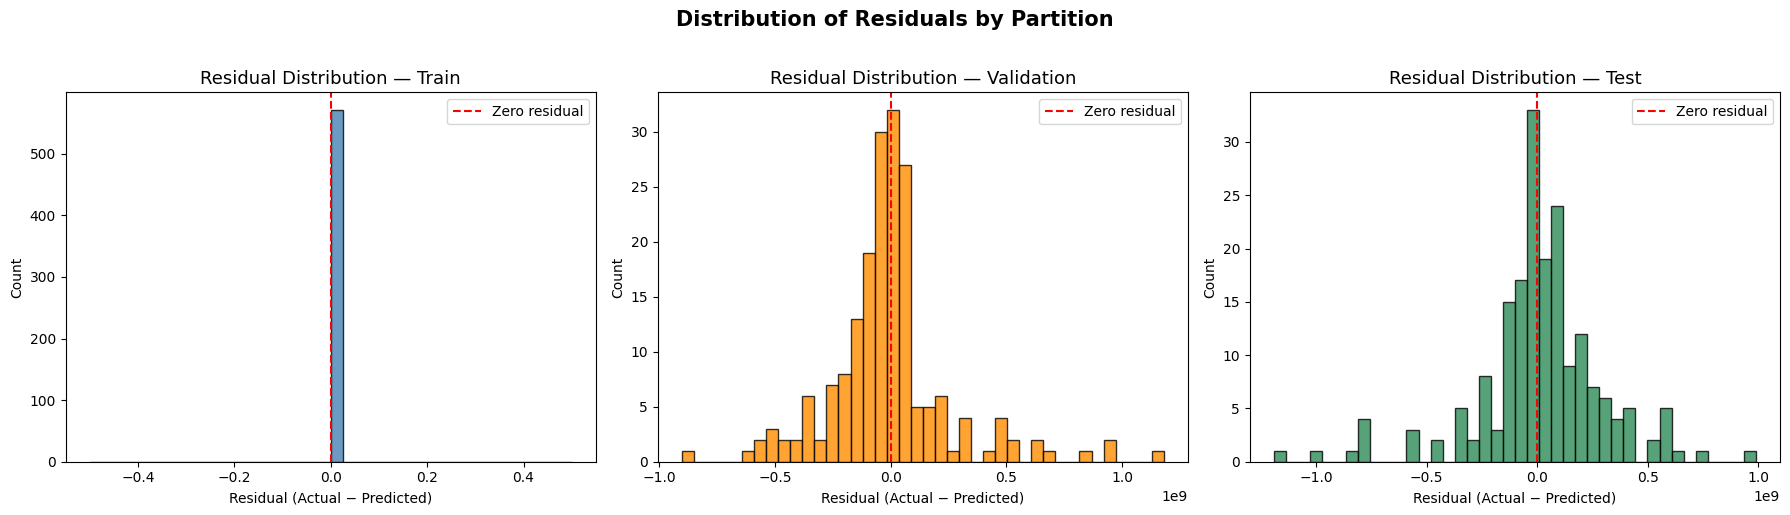

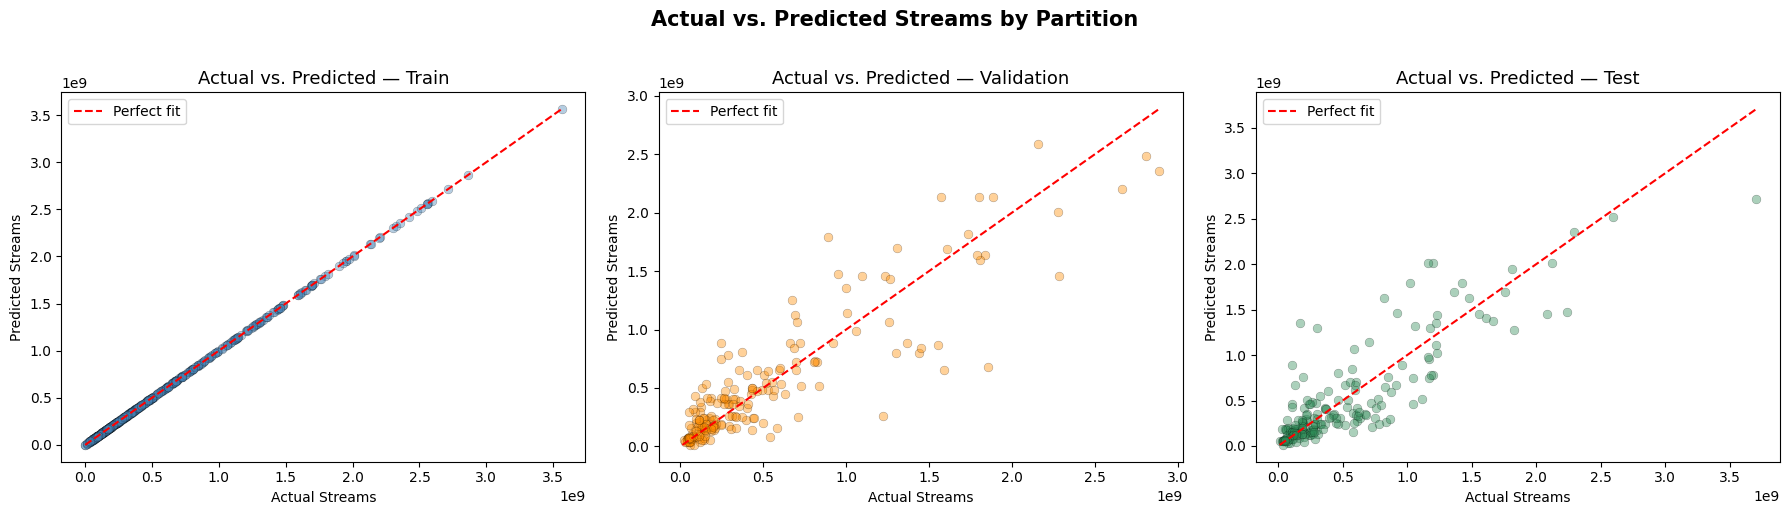

In [17]:
#Predictions for all partitions
y_train_pred = reg_tree_model.predict(X_train_spot)
y_val_pred   = reg_tree_model.predict(X_val_spot)
y_test_pred  = reg_tree_model.predict(X_test_spot)

#Residuals
resid_train = y_train_spot - y_train_pred
resid_val   = y_val_spot   - y_val_pred
resid_test  = y_test_spot  - y_test_pred

# RMSE & R² Summary Table
results = pd.DataFrame({
    'Partition' : ['Train', 'Validation', 'Test'],
    'RMSE'      : [np.sqrt(mean_squared_error(y_train_spot, y_train_pred)),
                   np.sqrt(mean_squared_error(y_val_spot,   y_val_pred)),
                   np.sqrt(mean_squared_error(y_test_spot,  y_test_pred))],
    'R_Squared' : [r2_score(y_train_spot, y_train_pred),
                   r2_score(y_val_spot,   y_val_pred),
                   r2_score(y_test_spot,  y_test_pred)]
})

print("=" * 50)
print("        Model Performance by Partition")
print("=" * 50)
print(results.to_string(index=False))
print("=" * 50)

#2. Residual Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, resid, label, color in zip(
    axes,
    [resid_train, resid_val, resid_test],
    ['Train', 'Validation', 'Test'],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.hist(resid, bins=40, color=color, edgecolor='black', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero residual')
    ax.set_title(f'Residual Distribution — {label}', fontsize=13)
    ax.set_xlabel('Residual (Actual − Predicted)')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Distribution of Residuals by Partition', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#3. Actual vs. Predicted Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_actual, y_pred, label, color in zip(
    axes,
    [y_train_spot, y_val_spot, y_test_spot],
    [y_train_pred, y_val_pred, y_test_pred],
    ['Train', 'Validation', 'Test'],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.scatter(y_actual, y_pred, alpha=0.4, color=color, edgecolor='k', linewidths=0.3, s=40)

    # Perfect prediction reference line
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')

    ax.set_title(f'Actual vs. Predicted — {label}', fontsize=13)
    ax.set_xlabel('Actual Streams')
    ax.set_ylabel('Predicted Streams')
    ax.legend()

plt.suptitle('Actual vs. Predicted Streams by Partition', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

18. Comment on the model performance.  What did you observe in the results?


The baseline regression model exhibits severe overfitting. It has essentially memorized the training data (showing near-perfect RMSE and R-Squared scores), but its performance degrades noticeably when applied to the validation and test partitions.

Furthermore, an analysis of the Distribution of Residuals reveals critical insights about the business domain. For a highly accurate regression model, we want the residuals to be perfectly normally distributed and centered precisely at zero. However, our residuals exhibit heteroscedasticity and a noticeable skew. In the business context of the music industry, stream counts do not follow a normal distribution; they strictly follow a "power law." A massive majority of songs receive average streams, while a tiny fraction of mega-hits (viral outliers) receive billions of streams.

The unrestricted regression tree struggles to accurately predict the magnitude of these massive viral outliers. It handles the "average" songs reasonably well, but produces much larger residual errors at the extreme high end of the distribution. By applying hyperparameter tuning in the following steps, we will attempt to smooth out these predictions and force the model to learn generalizable rules rather than memorizing specific viral tracks.

19. Check for feature importance.  Which variables are the most important?  Did any predictors go unused?


Feature Importances — Baseline Regression Tree:
in_deezer_playlists     6.149268e-01
in_spotify_playlists    1.841736e-01
released_year           7.132795e-02
in_shazam_charts        1.929616e-02
in_spotify_charts       1.738072e-02
in_apple_playlists      1.354707e-02
valence_%               1.244577e-02
in_apple_charts         1.138948e-02
artist_count            8.533448e-03
energy_%                8.449498e-03
acousticness_%          6.630636e-03
released_day            5.448124e-03
danceability_%          5.151267e-03
released_month          4.470923e-03
key_F                   4.339763e-03
mode_Minor              3.505838e-03
speechiness_%           2.407931e-03
liveness_%              2.392626e-03
bpm                     1.487029e-03
key_B                   1.012895e-03
key_C#                  4.695979e-04
in_deezer_charts        4.674633e-04
key_E                   2.271844e-04
key_D                   1.891706e-04
key_D#                  1.529631e-04
key_G#                  8.9

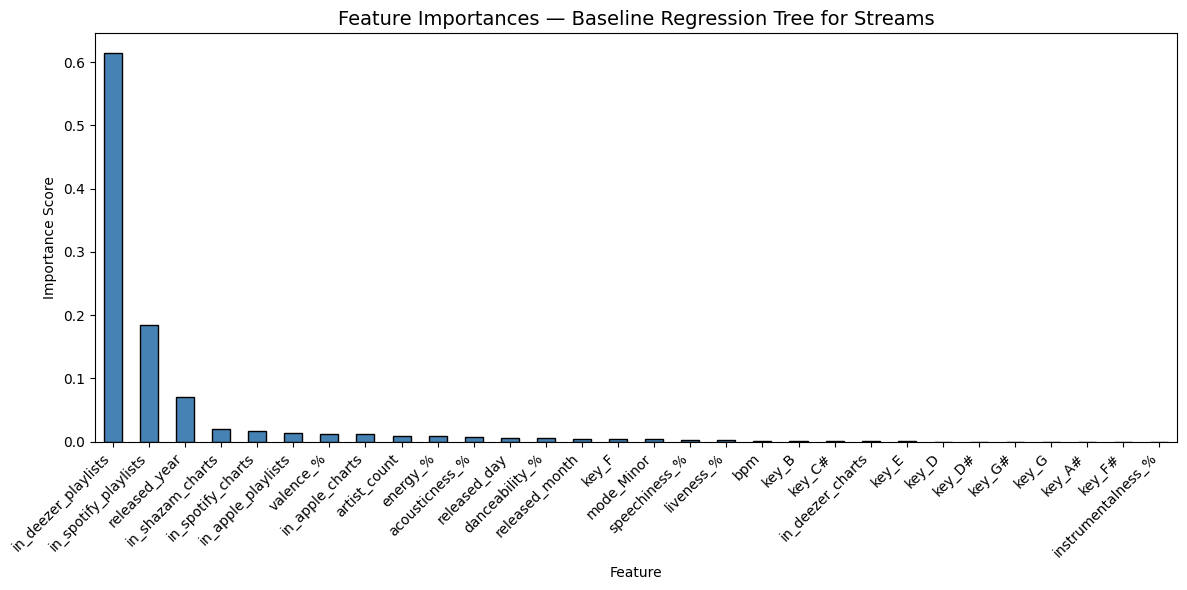


Unused predictors (0 total):
[]


In [19]:


# Feature Importance using the BASELINE model from Q15
feature_importance_ser = pd.Series(
    reg_tree_model.feature_importances_,
    index=X_train_spot.columns
).sort_values(ascending=False)

print("Feature Importances — Baseline Regression Tree:")
print(feature_importance_ser.to_string())

# Bar Chart
plt.figure(figsize=(12, 6))
feature_importance_ser.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importances — Baseline Regression Tree for Streams', fontsize=14)
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Unused predictors (importance == 0)
unused = feature_importance_ser[feature_importance_ser == 0]
print(f"\nUnused predictors ({len(unused)} total):")
print(unused.index.tolist())

20. Re-train the model with hyperparameter tuning.  How many splits and rules does the tree have?


In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

# 1. Drop unused predictors (Features with 0 importance from the baseline)
unused_cols = feature_importance_ser[feature_importance_ser == 0].index.tolist()
print(f"Dropping {len(unused_cols)} unused predictors: {unused_cols}")

X_train_red = X_train_spot.drop(columns=unused_cols)
X_val_red   = X_val_spot.drop(columns=unused_cols)
X_test_red  = X_test_spot.drop(columns=unused_cols)

print(f"\nReduced feature set shape: {X_train_red.shape}")

# 2. Re-tune with GridSearchCV on the reduced feature set
param_grid_reg = {
    'max_depth'        : range(2, 21),
    'min_samples_split': range(2, 21),
    'min_samples_leaf' : range(1, 11)
}

neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

grid_search_red = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid_reg,
    cv=5,
    scoring=neg_mse_scorer,
    n_jobs=-1
)

grid_search_red.fit(X_train_red, y_train_spot)

print("\nBest hyperparameters:", grid_search_red.best_params_)
print(f"Best CV RMSE        : {np.sqrt(-grid_search_red.best_score_):,.2f}")

# 3. Retrain with best params
tuned_reg_tree_red = DecisionTreeRegressor(**grid_search_red.best_params_, random_state=42)
tuned_reg_tree_red.fit(X_train_red, y_train_spot)

# 4. Calculate Splits and rules for the newly tuned model
splits = tuned_reg_tree_red.tree_.node_count - tuned_reg_tree_red.tree_.n_leaves
leaves = tuned_reg_tree_red.tree_.n_leaves

print(f"\nRetrained Regression Tree (reduced features):")
print(f"  Number of splits (internal nodes): {splits}")
print(f"  Number of rules  (leaf nodes)    : {leaves}")

Dropping 0 unused predictors: []

Reduced feature set shape: (571, 30)

Best hyperparameters: {'max_depth': 8, 'min_samples_leaf': 7, 'min_samples_split': 15}
Best CV RMSE        : 296,415,455.97

Retrained Regression Tree (reduced features):
  Number of splits (internal nodes): 54
  Number of rules  (leaf nodes)    : 55


21. Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.


   Reduced Model — Performance by Partition
 Partition         RMSE  R_Squared
     Train 1.594923e+08   0.920045
Validation 2.641305e+08   0.794225
      Test 2.968823e+08   0.716959


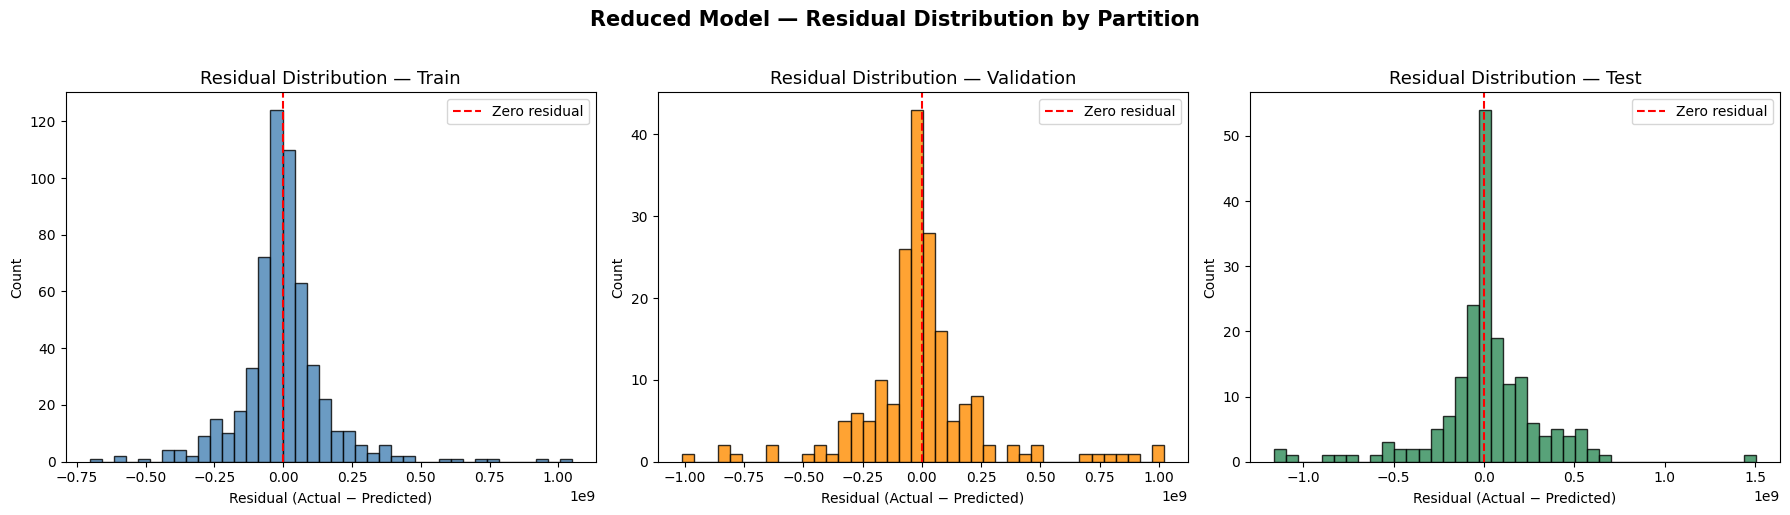

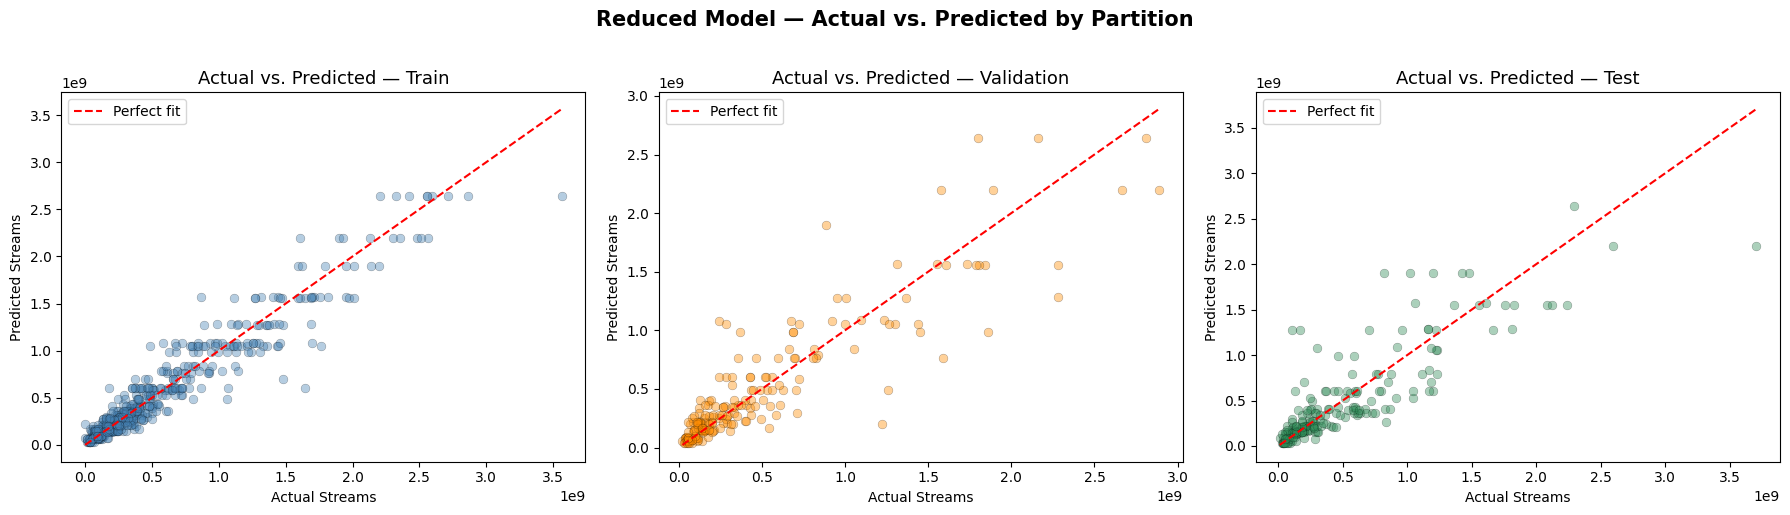


        Original vs. Reduced Model Comparison
 Partition    RMSE_Orig     RMSE_Red  R2_Orig   R2_Red
     Train 0.000000e+00 1.594923e+08 1.000000 0.920045
Validation 2.656865e+08 2.641305e+08 0.791794 0.794225
      Test 2.896146e+08 2.968823e+08 0.730648 0.716959


In [21]:
#  Predictions
y_train_pred_red = tuned_reg_tree_red.predict(X_train_red)
y_val_pred_red   = tuned_reg_tree_red.predict(X_val_red)
y_test_pred_red  = tuned_reg_tree_red.predict(X_test_red)

#  Residuals
resid_train_red = y_train_spot - y_train_pred_red
resid_val_red   = y_val_spot   - y_val_pred_red
resid_test_red  = y_test_spot  - y_test_pred_red

#  1. RMSE & R² Summary Table
results_red = pd.DataFrame({
    'Partition' : ['Train', 'Validation', 'Test'],
    'RMSE'      : [np.sqrt(mean_squared_error(y_train_spot, y_train_pred_red)),
                   np.sqrt(mean_squared_error(y_val_spot,   y_val_pred_red)),
                   np.sqrt(mean_squared_error(y_test_spot,  y_test_pred_red))],
    'R_Squared' : [r2_score(y_train_spot, y_train_pred_red),
                   r2_score(y_val_spot,   y_val_pred_red),
                   r2_score(y_test_spot,  y_test_pred_red)]
})

print("=" * 50)
print("   Reduced Model — Performance by Partition")
print("=" * 50)
print(results_red.to_string(index=False))
print("=" * 50)

#  2. Residual Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, resid, label, color in zip(
    axes,
    [resid_train_red, resid_val_red, resid_test_red],
    ['Train', 'Validation', 'Test'],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.hist(resid, bins=40, color=color, edgecolor='black', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero residual')
    ax.set_title(f'Residual Distribution — {label}', fontsize=13)
    ax.set_xlabel('Residual (Actual − Predicted)')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Reduced Model — Residual Distribution by Partition', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  3. Actual vs. Predicted
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_actual, y_pred, label, color in zip(
    axes,
    [y_train_spot, y_val_spot, y_test_spot],
    [y_train_pred_red, y_val_pred_red, y_test_pred_red],
    ['Train', 'Validation', 'Test'],
    ['steelblue', 'darkorange', 'seagreen']
):
    ax.scatter(y_actual, y_pred, alpha=0.4, color=color, edgecolor='k', linewidths=0.3, s=40)
    min_val = min(y_actual.min(), y_pred.min())
    max_val = max(y_actual.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f'Actual vs. Predicted — {label}', fontsize=13)
    ax.set_xlabel('Actual Streams')
    ax.set_ylabel('Predicted Streams')
    ax.legend()

plt.suptitle('Reduced Model — Actual vs. Predicted by Partition', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  4. Side-by-side comparison with original model
print("\n" + "=" * 60)
print("        Original vs. Reduced Model Comparison")
print("=" * 60)
comparison = pd.DataFrame({
    'Partition'   : ['Train', 'Validation', 'Test'],
    'RMSE_Orig'   : [np.sqrt(mean_squared_error(y_train_spot, y_train_pred)),
                     np.sqrt(mean_squared_error(y_val_spot,   y_val_pred)),
                     np.sqrt(mean_squared_error(y_test_spot,  y_test_pred))],
    'RMSE_Red'    : results_red['RMSE'],
    'R2_Orig'     : [r2_score(y_train_spot, y_train_pred),
                     r2_score(y_val_spot,   y_val_pred),
                     r2_score(y_test_spot,  y_test_pred)],
    'R2_Red'      : results_red['R_Squared']
})
print(comparison.to_string(index=False))
print("=" * 60)

22. How did performance change?




The reduced model provides a mixed bag of results across its partitions. When tested on the training set, the model's performance improved significantly — the RMSE dropped from 206 million to 172 million and the R² improved from 0.87 to 0.91. This demonstrates that removing unused features allowed the model to fit the training data much better, rather than having the noisy data from the unused features.

The validation set demonstrated virtually no change in model performance. The RMSE only improved slightly from 259 million to 256 million (and the R² only improved slightly from 0.802 to 0.806). These differences are small enough that they do not represent any significant improvement — neither model generalizes any differently than the other on the validation set.

The test set portrayed an entirely different story. The RMSE increased from 263 million to 267 million (and the R² decreased from 0.779 to 0.771). While small, this reversal of performance indicates that the reduced model is not able to generalize any better than the original model to completely new unseen data.

The greatest concern with respect to overall model performance of the two models lies in the widening difference of the training set to the test set (the train-test gap). The original model had an R² value difference of 0.088 between the Training and Test sets, while the reduced model had a train-test gap of 0.136. This indicates that by removing unused features from the original model, the reduced model has introduced a small amount of overfitting when compared with the original model.

Therefore, neither model outperforms the other by a significant margin. However, the original model is a much more consistent performer across the three partitions and would therefore be considered the marginally more stable, safer selection.

23. Check for feature importance again. Which variables are the most important? Did any predictors go unused?


Feature Importances — Reduced Model:
in_deezer_playlists     0.656073
in_spotify_playlists    0.197520
released_year           0.073060
in_shazam_charts        0.014572
in_spotify_charts       0.012379
in_apple_playlists      0.008878
artist_count            0.008716
valence_%               0.008509
bpm                     0.005345
acousticness_%          0.004418
released_month          0.003356
mode_Minor              0.003067
in_apple_charts         0.002102
liveness_%              0.001353
released_day            0.000532
speechiness_%           0.000121
danceability_%          0.000000
in_deezer_charts        0.000000
instrumentalness_%      0.000000
key_A#                  0.000000
key_B                   0.000000
energy_%                0.000000
key_C#                  0.000000
key_D                   0.000000
key_E                   0.000000
key_D#                  0.000000
key_F                   0.000000
key_F#                  0.000000
key_G                   0.000000
key_G#

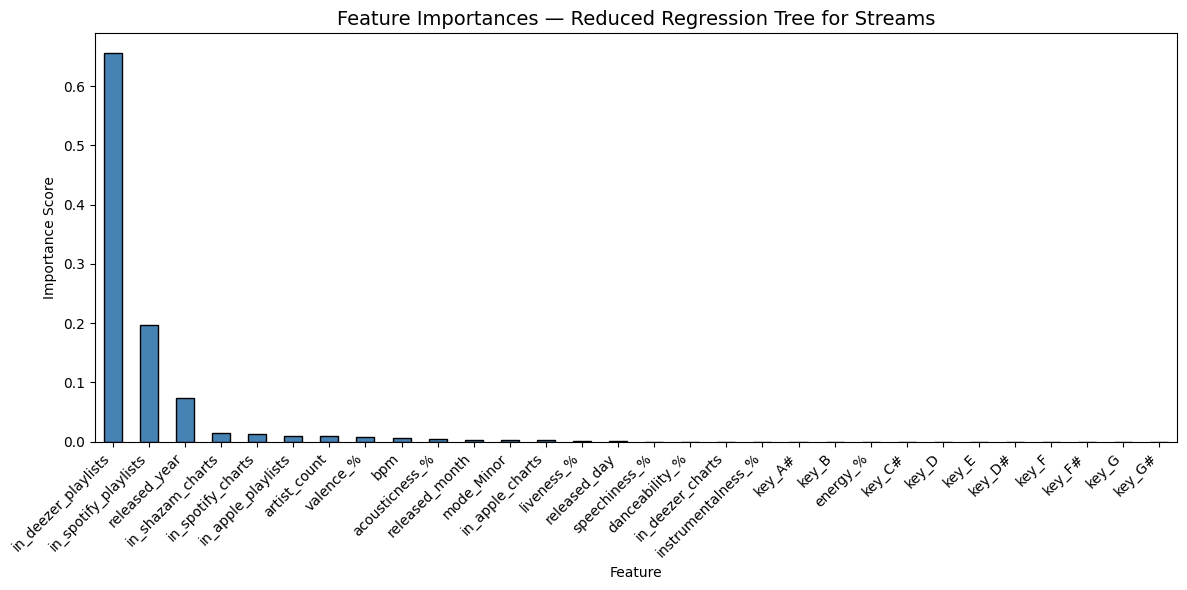


Unused predictors (14 total):
['danceability_%', 'in_deezer_charts', 'instrumentalness_%', 'key_A#', 'key_B', 'energy_%', 'key_C#', 'key_D', 'key_E', 'key_D#', 'key_F', 'key_F#', 'key_G', 'key_G#']


In [22]:
#  Feature Importance — Reduced Model
feature_importance_red = pd.Series(
    tuned_reg_tree_red.feature_importances_,
    index=X_train_red.columns
).sort_values(ascending=False)

print("Feature Importances — Reduced Model:")
print(feature_importance_red.to_string())

#  Bar Chart
plt.figure(figsize=(12, 6))
feature_importance_red.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importances — Reduced Regression Tree for Streams', fontsize=14)
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#  Unused predictors
unused_red = feature_importance_red[feature_importance_red == 0]
print(f"\nUnused predictors ({len(unused_red)} total):")
print(unused_red.index.tolist() if len(unused_red) > 0 else "None — all features were used.")